In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic' 
mpl.rcParams['axes.unicode_minus'] = False    

# 데이터 확인 및 전처리

In [2]:
import pandas as pd

files = [
    "2019-Oct.csv",
    "2019-Dec.csv",
    "2019-Nov.csv",
    "2020-Jan.csv",
    "2020-Feb.csv"
]

df = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)
df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


### 데이터 기본 정보 확인


In [6]:
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    20339246
brand             8757117
price                   0
user_id                 0
user_session         4598
dtype: int64

In [8]:
# price 분포 확인
df['price'].describe()
df=df[df['price'] >= 0]
# price가 음수인 경우는 분석에 사용하지 않으니 삭제

In [9]:
df['event_time']=pd.to_datetime(df['event_time'])

In [10]:
df['event_type'].value_counts()

event_type
view                9657819
cart                5768333
remove_from_cart    3979676
purchase            1286881
Name: count, dtype: int64

# 가설 검증


## 가설1: 탐색 부담 증가

첫 구매 이전, 첫 상품 조회부터 장바구니에 담기까지 발생한 탐색비용이 클수록
해당 신규 고객의 첫 구매 이후 30일 내 재구매 확률은 낮을 것이다.


### 관측기간 내 첫 구매 고객 식별


In [12]:
# purchase 이벤트만 필터링
purchase_df = df[df['event_type'] == 'purchase']

# user_id별 첫 구매 시점
first_purchase = purchase_df.groupby('user_id')['event_time'].min().reset_index()
first_purchase.columns = ['user_id', 'first_purchase_time']

In [14]:
first_purchase.shape,first_purchase['first_purchase_time'].min(),first_purchase['first_purchase_time'].max()

((110518, 2),
 Timestamp('2019-10-01 00:06:35+0000', tz='UTC'),
 Timestamp('2020-02-29 23:54:44+0000', tz='UTC'))

### 탐색비용 계산


In [15]:
df_merged = df.merge(first_purchase, on='user_id', how='inner')
# 첫 구매 이전 이벤트만 필터링
df_before_purchase = df_merged[df_merged['event_time'] < df_merged['first_purchase_time']]

In [16]:
# 신규 고객별 첫 view, 첫 cart 시점 구하기
# 첫 view 시점
first_view = df_before_purchase[df_before_purchase['event_type'] == 'view'] \
    .groupby('user_id')['event_time'].min().reset_index()
first_view.columns = ['user_id', 'first_view_time']

# 첫 cart 시점
first_cart = df_before_purchase[df_before_purchase['event_type'] == 'cart'] \
    .groupby('user_id')['event_time'].min().reset_index()
first_cart.columns = ['user_id', 'first_cart_time']

In [17]:
# 첫 view ~ 첫 cart 사이의 view 횟수 계산
# 첫 view, 첫 cart 시점 합치기
cost_df = first_view.merge(first_cart, on='user_id', how='inner')

# 첫 구매 이전 view 이벤트만
views_before = df_before_purchase[df_before_purchase['event_type'] == 'view'][['user_id', 'event_time']]

# cost_df에 합쳐서 첫 view ~ 첫 cart 사이의 view만 필터링
views_merged = views_before.merge(cost_df, on='user_id', how='inner')
views_in_range = views_merged[
    (views_merged['event_time'] >= views_merged['first_view_time']) &
    (views_merged['event_time'] < views_merged['first_cart_time'])
]

# 고객별 view 횟수 = 탐색비용
exploration_cost = views_in_range.groupby('user_id').size().reset_index(name='exploration_cost')

In [19]:
# 탐색비용 기초 통계량 확인
exploration_cost['exploration_cost'].describe()

count    71783.000000
mean         4.553919
std         11.221904
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       1425.000000
Name: exploration_cost, dtype: float64

In [20]:
# 재구매 변수 생성 
# 신규 고객별 첫 구매 이후 purchase 이벤트 필터링
df_after = df_merged[
    (df_merged['event_time'] > df_merged['first_purchase_time']) &
    (df_merged['event_type'] == 'purchase')
]

# 첫 구매 이후 30일 내 재구매 여부
df_after = df_after.merge(first_purchase, on='user_id', how='left')

# 30일 내 재구매한 고객 식별
repurchase_within_30 = df_after[
    df_after['event_time'] <= df_after['first_purchase_time_x'] + pd.Timedelta(days=30)
]['user_id'].unique()

# 결과 변수 생성
exploration_cost['repurchase'] = exploration_cost['user_id'].isin(repurchase_within_30).astype(int)

In [21]:
exploration_cost['repurchase'].value_counts() 

repurchase
0    62038
1     9745
Name: count, dtype: int64

관측기간 내 첫 구매 고객 전체를 기준으로 보면 이탈률은 약 90%이며,  
본 가설의 분석 대상인 장바구니 경험 고객 하위집단의 이탈률은 약 86%로 소폭 낮게 나타났다.

### 분포 확인 및 구간 설정


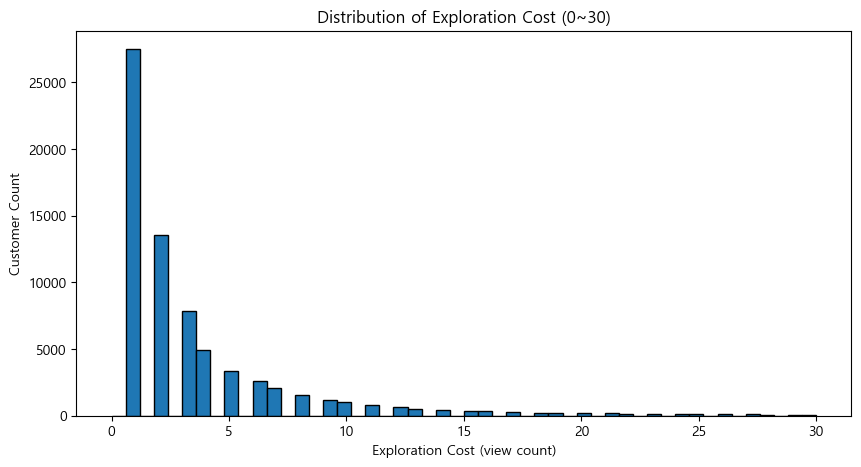

In [22]:
# 대부분이 몰려있는 구간만 먼저 보기
plt.figure(figsize=(10, 5))
plt.hist(exploration_cost['exploration_cost'], bins=50, range=(0, 30), edgecolor='black')
plt.xlabel('Exploration Cost (view count)')
plt.ylabel('Customer Count')
plt.title('Distribution of Exploration Cost (0~30)')
plt.show()

탐색비용 분포는 오른쪽 꼬리가 긴 형태로, 대부분의 고객이 낮은 탐색비용 구간에 집중되어 있다.
사분위수 기준으로 보면 25%가 1회, 50%가 2회, 75%가 5회이며, 이를 기반으로 다음과 같이 4개 그룹으로 구분한다.

Q1 (1회): 탐색 최소
Q2 (2회): 탐색 낮음
Q3 (3~5회): 탐색 중간
Q4 (6회 이상): 탐색 높음

먼저 4그룹 간 재구매율의 전체적인 추세를 확인한 뒤,
상위 구간(Q4)을 세분화하여 재구매율이 급격히 하락하는 임계점 존재 여부를 추가로 탐색한다.

### 구간별 재구매율 비교


In [23]:
# 구간 설정
def assign_group(cost):
    if cost == 1:
        return 'Q1 (1)'
    elif cost == 2:
        return 'Q2 (2)'
    elif cost <= 5:
        return 'Q3 (3~5)'
    else:
        return 'Q4 (6+)'

exploration_cost['cost_group'] = exploration_cost['exploration_cost'].apply(assign_group)

# 그룹별 재구매율
group_stats = exploration_cost.groupby('cost_group').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['Q1 (1)', 'Q2 (2)', 'Q3 (3~5)', 'Q4 (6+)'])

print(group_stats)

            customer_count  repurchase_rate
cost_group                                 
Q1 (1)               27487         0.119074
Q2 (2)               13513         0.129209
Q3 (3~5)             16158         0.143830
Q4 (6+)              14625         0.164239


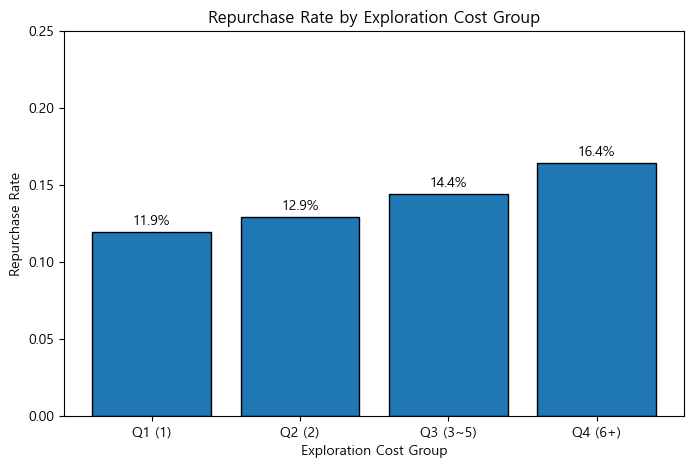

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(group_stats.index, group_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Exploration Cost Group')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate by Exploration Cost Group')
plt.ylim(0, 0.25)

# 각 막대 위에 수치 표시
for i, v in enumerate(group_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()
 삽입

가설과 반대로, 탐색 비용이 높을수록 재구매율은 오히려 증가하는 패턴이 나타났다.  
이는 탐색 부담이 단순한 피로의 지표라기보다, 상품에 대한 관심과 비교 행동, 그리고 구매 확신 형성 과정을 함께 반영하는 변수일 가능성을 시사한다.  
즉, 충분히 탐색한 고객일수록 이후 재구매로 이어질 가능성이 더 높았다.

### 상위 구간 세분화 (임계점 탐색)


          customer_count  repurchase_rate
q4_group                                 
6~10                8404         0.151594
11~15               2770         0.172924
16~20               1253         0.177175
21~30               1107         0.162602
31+                 1091         0.226398


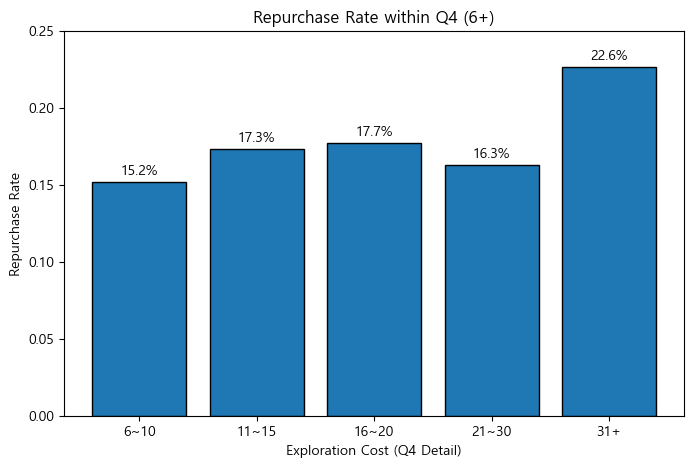

In [25]:
# Q4 고객만 필터링
q4 = exploration_cost[exploration_cost['exploration_cost'] >= 6].copy()

# 세분화 구간 설정
def assign_q4_detail(cost):
    if cost <= 10:
        return '6~10'
    elif cost <= 15:
        return '11~15'
    elif cost <= 20:
        return '16~20'
    elif cost <= 30:
        return '21~30'
    else:
        return '31+'

q4['q4_group'] = q4['exploration_cost'].apply(assign_q4_detail)

# 그룹별 재구매율
q4_stats = q4.groupby('q4_group').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['6~10', '11~15', '16~20', '21~30', '31+'])

print(q4_stats)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(q4_stats.index, q4_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Exploration Cost (Q4 Detail)')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate within Q4 (6+)')
plt.ylim(0, 0.25)

for i, v in enumerate(q4_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()

In [26]:
q4_31plus = exploration_cost[exploration_cost['exploration_cost'] >= 31]

print(q4_31plus['exploration_cost'].describe())
print()
print('50회 이상:', len(q4_31plus[q4_31plus['exploration_cost'] >= 50]))
print('100회 이상:', len(q4_31plus[q4_31plus['exploration_cost'] >= 100]))
print('500회 이상:', len(q4_31plus[q4_31plus['exploration_cost'] >= 500]))

count    1091.000000
mean       59.258478
std        63.295036
min        31.000000
25%        36.000000
50%        44.000000
75%        63.000000
max      1425.000000
Name: exploration_cost, dtype: float64

50회 이상: 444
100회 이상: 95
500회 이상: 2


In [27]:
def assign_q4_extended(cost):
    if cost <= 10:
        return '6~10'
    elif cost <= 20:
        return '11~20'
    elif cost <= 30:
        return '21~30'
    elif cost <= 50:
        return '31~50'
    elif cost <= 100:
        return '51~100'
    else:
        return '100+'

q4['q4_ext'] = q4['exploration_cost'].apply(assign_q4_extended)

q4_ext_stats = q4.groupby('q4_ext').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['6~10', '11~20', '21~30', '31~50', '51~100', '100+'])

print(q4_ext_stats)

        customer_count  repurchase_rate
q4_ext                                 
6~10              8404         0.151594
11~20             4023         0.174248
21~30             1107         0.162602
31~50              666         0.217718
51~100             333         0.234234
100+                92         0.260870


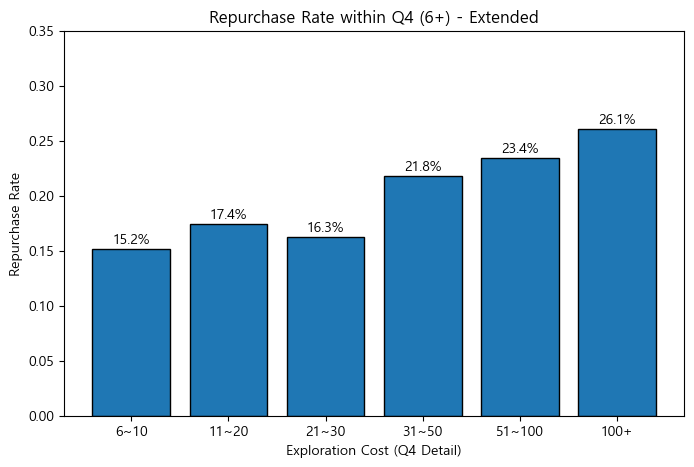

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(q4_ext_stats.index, q4_ext_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Exploration Cost (Q4 Detail)')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate within Q4 (6+) - Extended')
plt.ylim(0, 0.35)

for i, v in enumerate(q4_ext_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()
 삽입
# 건 "혹시 극단 구간에서 떨어지지 않나?" 확인한 근거예요. 임계점이 없다는 결론을 뒷받침해줌

상위구간(Q4)을 세분화한 결과에서도 재구매율이 하락하는 임계점은 관찰되지 않았다.  
탐색 비용이 100회를 초과하는 극단적 구간에서도 재구매율은 26.1%로 가장 높게 나타났다.  
이는 탐색 부담이 이탈을 유발하는 부정적 요인이 아니라, 고객의 제품 관여도를 반영하는 지표일 가능성이 높음을 보여준다.

### 통계 검정
카이제곱 검정으로 그룹 간 차이의 유의성을 확인하고, 로지스틱 회귀로 영향 크기를 추정한다.


In [29]:
from scipy.stats import chi2_contingency

# 그룹별 재구매/미재구매 교차표
crosstab = pd.crosstab(exploration_cost['cost_group'], exploration_cost['repurchase'])
crosstab = crosstab.reindex(['Q1 (1)', 'Q2 (2)', 'Q3 (3~5)', 'Q4 (6+)'])

chi2, p_value, dof, expected = chi2_contingency(crosstab)

print(f'카이제곱 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.6f}')
print(f'자유도: {dof}')

카이제곱 통계량: 180.2373
p-value: 0.000000
자유도: 3


In [30]:
from sklearn.linear_model import LogisticRegression
import numpy as np

X = exploration_cost[['exploration_cost']]
y = exploration_cost['repurchase']

model = LogisticRegression()
model.fit(X, y)

coef = model.coef_[0][0]
odds_ratio = np.exp(coef)

print(f'회귀 계수: {coef:.6f}')
print(f'오즈비: {odds_ratio:.4f}')
print(f'해석: 탐색비용 1회 증가 시 재구매 오즈가 {odds_ratio:.4f}배 변화')

회귀 계수: 0.008159
오즈비: 1.0082
해석: 탐색비용 1회 증가 시 재구매 오즈가 1.0082배 변화


In [31]:
# 상위 1% 기준점 확인
p99 = exploration_cost['exploration_cost'].quantile(0.99)
print(f'상위 1% 기준: {p99}')

# IQR 기준 상한
Q1 = exploration_cost['exploration_cost'].quantile(0.25)
Q3 = exploration_cost['exploration_cost'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
print(f'IQR 상한: {upper}')

# IQR 기준으로 필터링
ec_filtered = exploration_cost[exploration_cost['exploration_cost'] <= upper].copy()
print(f'필터링 전: {len(exploration_cost)}명')
print(f'필터링 후: {len(ec_filtered)}명')

# 카이제곱 재검정
crosstab_f = pd.crosstab(ec_filtered['cost_group'], ec_filtered['repurchase'])
crosstab_f = crosstab_f.reindex(['Q1 (1)', 'Q2 (2)', 'Q3 (3~5)', 'Q4 (6+)'])
chi2_f, p_f, dof_f, _ = chi2_contingency(crosstab_f)
print(f'\n[이상치 제거 후 카이제곱]')
print(f'카이제곱 통계량: {chi2_f:.4f}')
print(f'p-value: {p_f:.6f}')

# 로지스틱 회귀 재검정
X_f = ec_filtered[['exploration_cost']]
y_f = ec_filtered['repurchase']
model_f = LogisticRegression()
model_f.fit(X_f, y_f)
coef_f = model_f.coef_[0][0]
odds_f = np.exp(coef_f)
print(f'\n[이상치 제거 후 로지스틱 회귀]')
print(f'회귀 계수: {coef_f:.6f}')
print(f'오즈비: {odds_f:.4f}')

상위 1% 기준: 38.0
IQR 상한: 11.0
필터링 전: 71783명
필터링 후: 66336명

[이상치 제거 후 카이제곱]
카이제곱 통계량: 98.9769
p-value: 0.000000

[이상치 제거 후 로지스틱 회귀]
회귀 계수: 0.044054
오즈비: 1.0450


카이제곱 검정 결과, 탐색 비용 그룹 간 재구매율 차이는 통계적으로 유의하였다 (p < 0.001).  
로지스틱 회귀 결과에서도 탐색 비용이 증가할수록 재구매 오즈가 증가하는 방향이 확인되었다.  
극단값 제거 후에도 동일한 방향성이 유지되어, 해당 패턴이 특정 일부 구간이나 이상치에 의해 발생한 현상은 아님을 확인하였다.

## 가설2: 상대적 가격 혜택 경험 부족

할인의 크기에 상관없이 할인 혜택을 경험하지 못한 사람은 경험한 사람보다 재구매확률이 낮을 것이다.


### 변수 정의 및 할인 경험 산출


In [32]:
# 재구매 유저
repurchase_users = df_merged[
    (df_merged['event_time'] > df_merged['first_purchase_time']) &
    (df_merged['event_time'] <= df_merged['first_purchase_time'] + pd.Timedelta(days=30)) &
    (df_merged['event_type'] == 'purchase')
]['user_id'].unique()

In [33]:
# 상품별 기준가 계산

# purchase 이벤트에서 상품별 평균 가격 계산
product_avg_price = df[df['event_type'] == 'purchase'].groupby('product_id')['price'].mean().reset_index()
product_avg_price.columns = ['product_id', 'avg_price']

In [34]:
# 신규 고객의 첫 구매일 이벤트만 필터링
first_purchase_events = df_merged[
    (df_merged['event_type'] == 'purchase') &
    (df_merged['event_time'].dt.date == df_merged['first_purchase_time'].dt.date)
]

# 상품별 기준가 붙이기
first_purchase_events = first_purchase_events.merge(product_avg_price, on='product_id', how='left')

# 각 거래별 할인 여부
first_purchase_events['is_discount'] = (first_purchase_events['price'] < first_purchase_events['avg_price']).astype(int)

# 고객별 할인 경험 여부 (하나라도 할인이면 1)
discount_experience = first_purchase_events.groupby('user_id')['is_discount'].max().reset_index()
discount_experience.columns = ['user_id', 'discount_exp']

In [35]:
discount_experience['repurchase'] = discount_experience['user_id'].isin(repurchase_users).astype(int)

In [37]:
discount_experience.shape,discount_experience['discount_exp'].value_counts(),discount_experience.groupby('discount_exp')['repurchase'].mean()

((110518, 3),
 discount_exp
 0    77170
 1    33348
 Name: count, dtype: int64,
 discount_exp
 0    0.13075
 1    0.15935
 Name: repurchase, dtype: float64)

### 통계 검정
카이제곱 검정으로 그룹 간 차이의 유의성을 확인하고, 로지스틱 회귀로 영향 크기를 추정한다.


In [38]:
# 카이제곱 검정
crosstab_h2 = pd.crosstab(discount_experience['discount_exp'], discount_experience['repurchase'])
chi2_h2, p_h2, dof_h2, _ = chi2_contingency(crosstab_h2)

print(f'카이제곱 통계량: {chi2_h2:.4f}')
print(f'p-value: {p_h2:.6f}')

카이제곱 통계량: 158.5407
p-value: 0.000000


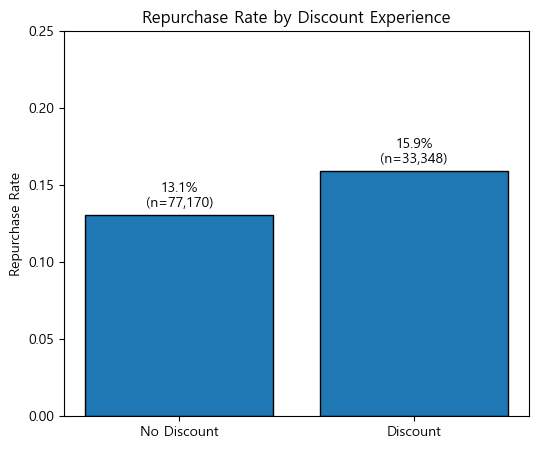

In [39]:
labels = ['No Discount', 'Discount']
rates = [0.13075, 0.15935]
counts = [77170, 33348]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, rates, edgecolor='black')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate by Discount Experience')
plt.ylim(0, 0.25)

for i, v in enumerate(rates):
    plt.text(i, v + 0.005, f'{v:.1%}\n(n={counts[i]:,})', ha='center')

plt.show()

할인을 경험한 고객의 재구매율은 15.9%, 미경험 고객은 13.1%로 약 2.8%p 차이가 나타났다. 카이제곱 검정 결과 이 차이는 통계적으로 유의하였다.
할인 경험 유무가 재구매와 관련이 있음을 시사하며, 구체적으로 몇 회, 언제 경험해야 효과적인지를 심화 분석에서 추가로 확인이 필요해 보인다.

### 심화 분석 1: 할인 경험 횟수별 재구매율


In [40]:
# 고객별 할인 경험 횟수
discount_count = first_purchase_events.groupby('user_id')['is_discount'].sum().reset_index()
discount_count.columns = ['user_id', 'discount_count']

# 재구매 여부 붙이기
discount_count['repurchase'] = discount_count['user_id'].isin(repurchase_users).astype(int)

# 분포 확인
print(discount_count['discount_count'].describe())
print()
print(discount_count['discount_count'].value_counts().sort_index().head(10))

count    110518.000000
mean          1.069283
std           3.601837
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         179.000000
Name: discount_count, dtype: float64

discount_count
0    77170
1    17117
2     5606
3     2534
4     1628
5     1104
6      804
7      650
8      531
9      472
Name: count, dtype: int64


          customer_count  repurchase_rate
dc_group                                 
0회                 77170         0.130750
1회                 17117         0.147982
2~3회                8140         0.175799
4회+                 8091         0.166852


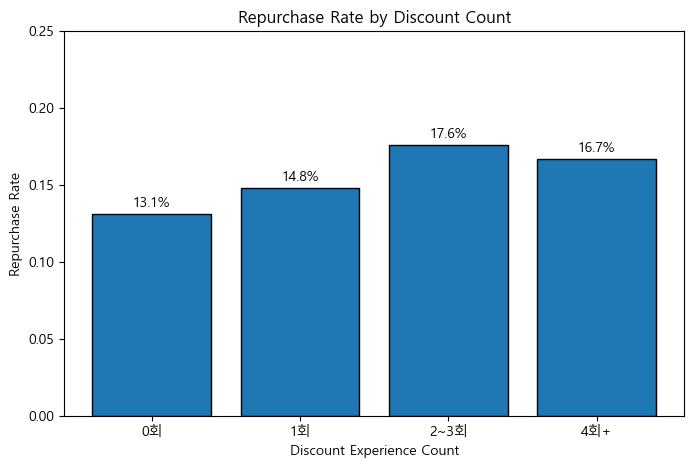

In [41]:
def assign_discount_group(count):
    if count == 0:
        return '0회'
    elif count == 1:
        return '1회'
    elif count <= 3:
        return '2~3회'
    else:
        return '4회+'

discount_count['dc_group'] = discount_count['discount_count'].apply(assign_discount_group)

dc_stats = discount_count.groupby('dc_group').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['0회', '1회', '2~3회', '4회+'])

print(dc_stats)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(dc_stats.index, dc_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Discount Experience Count')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate by Discount Count')
plt.ylim(0, 0.25)

for i, v in enumerate(dc_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()

가격 혜택 경험 횟수가 증가할수록 재구매율은 0회(13.1%) → 1회(14.8%) → 2~ 3회(17.6%)까지 상승하였다.  
반면 4회 이상에서는 16.7% 수준으로 소폭 낮아지며, 추가 효과는 제한적으로 나타났다.  
이는 초기 2~ 3회의 가격 혜택 경험이 가장 효과적인 구간일 가능성을 시사한다.

In [42]:
# 4회 이상 고객만 필터링
dc_4plus = discount_count[discount_count['discount_count'] >= 4].copy()

def assign_dc_detail(count):
    if count <= 5:
        return '4~5회'
    elif count <= 8:
        return '6~8회'
    elif count <= 15:
        return '9~15회'
    else:
        return '16회+'

dc_4plus['dc_detail'] = dc_4plus['discount_count'].apply(assign_dc_detail)

dc_detail_stats = dc_4plus.groupby('dc_detail').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['4~5회', '6~8회', '9~15회', '16회+'])

print(dc_detail_stats)

           customer_count  repurchase_rate
dc_detail                                 
4~5회                 2732         0.161054
6~8회                 1985         0.161713
9~15회                2077         0.157920
16회+                 1297         0.201234


In [43]:
print(dc_4plus['discount_count'].describe())
print()
print('20회 이상:', len(dc_4plus[dc_4plus['discount_count'] >= 20]))
print('50회 이상:', len(dc_4plus[dc_4plus['discount_count'] >= 50]))
print('100회 이상:', len(dc_4plus[dc_4plus['discount_count'] >= 100]))

count    8091.000000
mean       10.164875
std         9.044445
min         4.000000
25%         5.000000
50%         7.000000
75%        12.000000
max       179.000000
Name: discount_count, dtype: float64

20회 이상: 794
50회 이상: 58
100회 이상: 5


           customer_count  repurchase_rate
dc_detail                                 
4~5회                 2732         0.161054
6~8회                 1985         0.161713
9~12회                1431         0.160727
13~22회               1396         0.169771


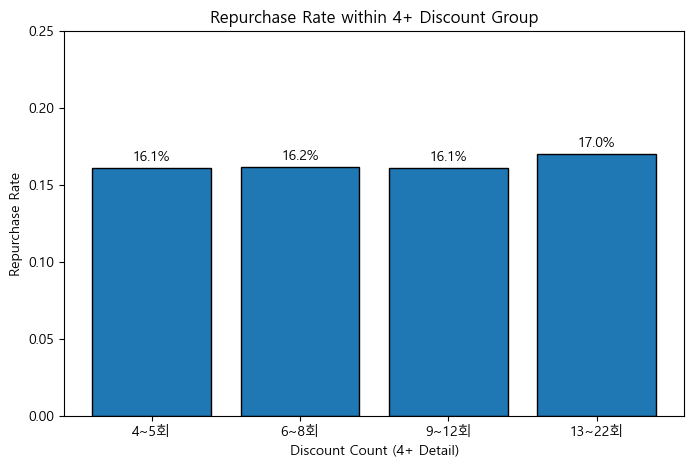

In [44]:
# 이상치 제외 
dc_4plus_clean = dc_4plus[dc_4plus['discount_count'] <= 22].copy()

def assign_dc_detail(count):
    if count <= 5:
        return '4~5회'
    elif count <= 8:
        return '6~8회'
    elif count <= 12:
        return '9~12회'
    else:
        return '13~22회'

dc_4plus_clean['dc_detail'] = dc_4plus_clean['discount_count'].apply(assign_dc_detail)

dc_detail_stats = dc_4plus_clean.groupby('dc_detail').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['4~5회', '6~8회', '9~12회', '13~22회'])

print(dc_detail_stats)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(dc_detail_stats.index, dc_detail_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Discount Count (4+ Detail)')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate within 4+ Discount Group')
plt.ylim(0, 0.25)

for i, v in enumerate(dc_detail_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()

할인 횟수별로 구간을 나눈 결과, 0회(13.1%) → 1회(14.8%) → 2~ 3회(17.6%)까지 재구매율이 증가하였으나, 4회 이상에서는 16.1~ 17.0%로 정체되었다. 이상치(IQR 기준 23회 이상) 제거 후에도 4회 이상 전 구간에서 동일한 정체 패턴이 확인되었다.
이는 할인 경험의 효과가 2~3회에서 최대화되며, 그 이상의 반복은 추가적인 재구매율 향상으로 이어지지 않음을 의미한다.

### 심화 분석 2: 재구매 시점 비교


count    10335.000000
mean        33.503435
std         31.303041
min          0.000000
25%          9.000000
50%         26.000000
75%         48.000000
max        151.000000
Name: days_to_repurchase, dtype: float64


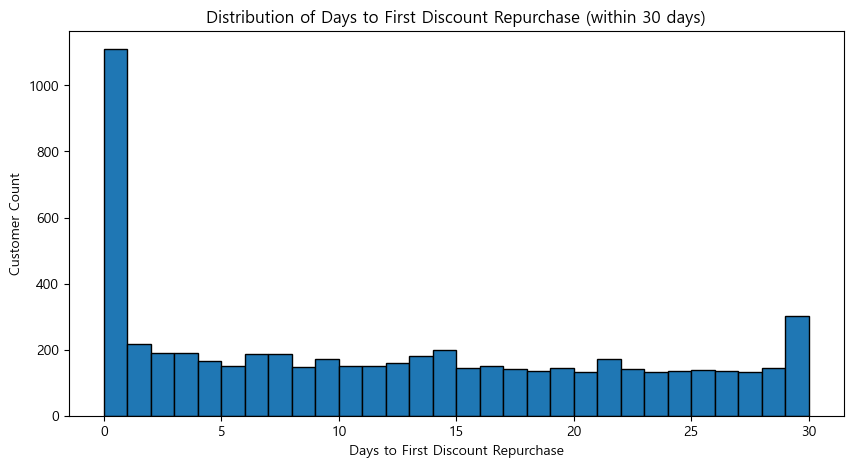

In [50]:
# 첫 구매 이후 purchase 이벤트 중 할인 경험한 건만
after_purchase = df_merged[
    (df_merged['event_time'] > df_merged['first_purchase_time']) &
    (df_merged['event_type'] == 'purchase')
].copy()

after_purchase = after_purchase.merge(product_avg_price, on='product_id', how='left')
after_purchase['is_discount'] = (after_purchase['price'] < after_purchase['avg_price']).astype(int)

# 할인 경험한 재구매 건만 필터링
after_discount = after_purchase[after_purchase['is_discount'] == 1].copy()

# 첫 구매 후 며칠 만에 할인 재구매했는지
after_discount['days_to_repurchase'] = (after_discount['event_time'] - after_discount['first_purchase_time']).dt.days

# 고객별 첫 할인 재구매까지의 일수
first_discount_repurchase = after_discount.groupby('user_id')['days_to_repurchase'].min().reset_index()

print(first_discount_repurchase['days_to_repurchase'].describe())

# 분포 시각화
plt.figure(figsize=(10, 5))
plt.hist(first_discount_repurchase['days_to_repurchase'], bins=30, range=(0, 30), edgecolor='black')
plt.xlabel('Days to First Discount Repurchase')
plt.ylabel('Customer Count')
plt.title('Distribution of Days to First Discount Repurchase (within 30 days)')
plt.show()

In [51]:
# 구간별 고객 수 비교
timing = first_discount_repurchase['days_to_repurchase']

print('0~1일:', len(timing[timing <= 1]))
print('2~3일:', len(timing[(timing >= 2) & (timing <= 3)]))
print('4~7일:', len(timing[(timing >= 4) & (timing <= 7)]))
print('8~14일:', len(timing[(timing >= 8) & (timing <= 14)]))
print('15~30일:', len(timing[(timing >= 15) & (timing <= 30)]))

# 30일 내 기준으로 비율
within_30 = timing[timing <= 30]
print(f'\n30일 내 전체: {len(within_30)}명')
print(f'3일 내 비율: {len(timing[timing <= 3]) / len(within_30):.1%}')
print(f'7일 내 비율: {len(timing[timing <= 7]) / len(within_30):.1%}')

0~1일: 1327
2~3일: 380
4~7일: 689
8~14일: 1163
15~30일: 2276

30일 내 전체: 5835명
3일 내 비율: 29.3%
7일 내 비율: 41.1%


In [52]:
within_30 = first_discount_repurchase[first_discount_repurchase['days_to_repurchase'] <= 30].copy()
daily_counts = within_30['days_to_repurchase'].value_counts().sort_index()
cumulative_ratio = daily_counts.cumsum() / daily_counts.sum()

# 과반 넘는 시점 찾기
for day, ratio in cumulative_ratio.items():
    if ratio >= 0.5:
        print(f'과반 돌파: {day}일 ({ratio:.1%})')
        break

# 주요 시점 비율
for day in [1, 3, 7, 14]:
    if day in cumulative_ratio.index:
        print(f'{day}일까지: {cumulative_ratio[day]:.1%}')

과반 돌파: 11일 (51.7%)
1일까지: 22.7%
3일까지: 29.3%
7일까지: 41.1%
14일까지: 61.0%


In [53]:
# 30일 내로 필터링 + 재구매 시점 계산
after_repurchase = after_purchase[
    (after_purchase['event_time'] <= after_purchase['first_purchase_time'] + pd.Timedelta(days=30))
].copy()

after_repurchase['days'] = (after_repurchase['event_time'] - after_repurchase['first_purchase_time']).dt.days
first_repurchase_day = after_repurchase.groupby('user_id').agg(
    days_to_repurchase=('days', 'min'),
    has_discount=('is_discount', 'max')
).reset_index()

discount_group = first_repurchase_day[first_repurchase_day['has_discount'] == 1]['days_to_repurchase']
no_discount_group = first_repurchase_day[first_repurchase_day['has_discount'] == 0]['days_to_repurchase']

할인 경험 (1일 이후):
count    4393.000000
mean       12.861598
std         8.265404
min         1.000000
25%         6.000000
50%        12.000000
75%        20.000000
max        29.000000
Name: days_to_repurchase, dtype: float64

미경험 (1일 이후):
count    7284.000000
mean       13.370126
std         8.446601
min         1.000000
25%         6.000000
50%        13.000000
75%        20.000000
max        29.000000
Name: days_to_repurchase, dtype: float64


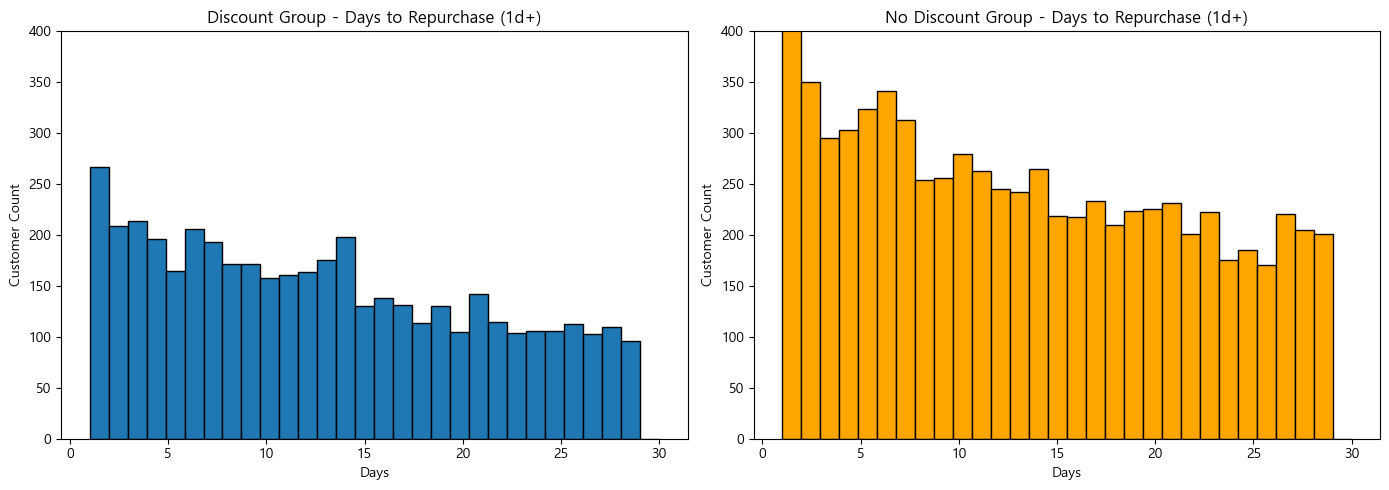

In [54]:
# 당일(0일)만 제외
discount_filtered = discount_group[discount_group >= 1]
no_discount_filtered = no_discount_group[no_discount_group >= 1]

print('할인 경험 (1일 이후):')
print(discount_filtered.describe())
print(f'\n미경험 (1일 이후):')
print(no_discount_filtered.describe())

# 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(discount_filtered, bins=30, range=(1, 30), edgecolor='black')
axes[0].set_title('Discount Group - Days to Repurchase (1d+)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Customer Count')
axes[0].set_ylim(0, 400)

axes[1].hist(no_discount_filtered, bins=30, range=(1, 30), edgecolor='black', color='orange')
axes[1].set_title('No Discount Group - Days to Repurchase (1d+)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Customer Count')
axes[1].set_ylim(0, 400)

plt.tight_layout()
plt.show()

분석 결과, 할인 경험 고객의 재구매 시점 중위값은 12일, 미경험 고객은 13일로 두 그룹 간 유의미한 차이가 관찰되지 않았다. 분포 형태 역시 유사하였다.
이는 할인 경험의 효과가 재구매 시점을 앞당기는 것이 아니라, 재구매 자체와 더 강하게 연관되어 있음을 시사한다. 즉, 할인은 재구매 시점을 앞당기기 보다는 재구매로
전환될 가능성이 낮았던 고객의 재구매 발생을 촉진하는 방향으로 작용했을 가능성이 있다.

## 가설3: 첫 구매 상품 다양성 부족

첫 구매에서 상품의 다양성이 낮은 고객은 다양하게 구매하는 고객보다 재구매 확률이 낮을 것이다.


In [55]:
# 신규 고객의 첫 구매일 purchase 이벤트
first_day_purchase = df_merged[
    (df_merged['event_type'] == 'purchase') &
    (df_merged['event_time'].dt.date == df_merged['first_purchase_time'].dt.date)
]

# 고객별 고유 상품 수
product_diversity = first_day_purchase.groupby('user_id')['product_id'].nunique().reset_index()
product_diversity.columns = ['user_id', 'unique_products']

# 재구매 여부 붙이기
product_diversity['repurchase'] = product_diversity['user_id'].isin(repurchase_users).astype(int)

In [56]:
product_diversity.shape,product_diversity['unique_products'].describe(),product_diversity['unique_products'].value_counts().sort_index().head(10) 

((110518, 3),
 count    110518.000000
 mean          7.728026
 std           9.092530
 min           1.000000
 25%           3.000000
 50%           5.000000
 75%          10.000000
 max         429.000000
 Name: unique_products, dtype: float64,
 unique_products
 1     12921
 2     13029
 3     12796
 4     11038
 5      8892
 6      7438
 7      6029
 8      5256
 9      4519
 10     3888
 Name: count, dtype: int64)

           customer_count  repurchase_rate
div_group                                 
Q1 (1~2)            25950         0.081079
Q2 (3~5)            32726         0.120944
Q3 (6~10)           27130         0.159676
Q4 (11+)            24712         0.202736


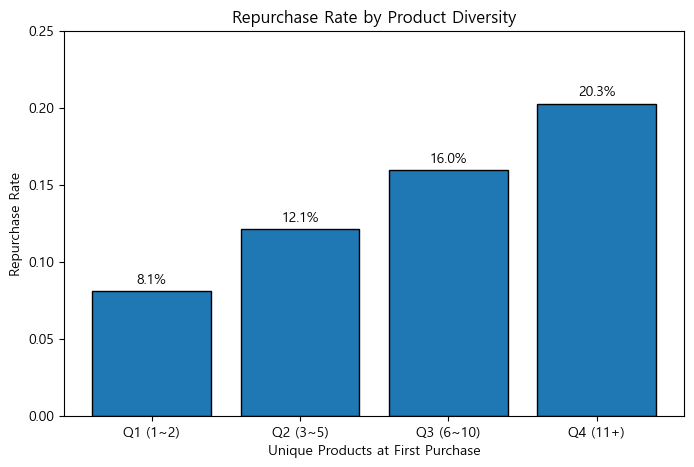

In [57]:
def assign_diversity_group(n):
    if n <= 2:
        return 'Q1 (1~2)'
    elif n <= 5:
        return 'Q2 (3~5)'
    elif n <= 10:
        return 'Q3 (6~10)'
    else:
        return 'Q4 (11+)'

product_diversity['div_group'] = product_diversity['unique_products'].apply(assign_diversity_group)

div_stats = product_diversity.groupby('div_group').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['Q1 (1~2)', 'Q2 (3~5)', 'Q3 (6~10)', 'Q4 (11+)'])

print(div_stats)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(div_stats.index, div_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Unique Products at First Purchase')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate by Product Diversity')
plt.ylim(0, 0.25)

for i, v in enumerate(div_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()

### 통계 검정
카이제곱 검정으로 그룹 간 차이의 유의성을 확인하고, 로지스틱 회귀로 영향 크기를 추정한다.


In [58]:
# 카이제곱 검정
crosstab_h3 = pd.crosstab(product_diversity['div_group'], product_diversity['repurchase'])
crosstab_h3 = crosstab_h3.reindex(['Q1 (1~2)', 'Q2 (3~5)', 'Q3 (6~10)', 'Q4 (11+)'])
chi2_h3, p_h3, dof_h3, _ = chi2_contingency(crosstab_h3)

print(f'카이제곱 통계량: {chi2_h3:.4f}')
print(f'p-value: {p_h3:.6f}')

# 로지스틱 회귀
X_h3 = product_diversity[['unique_products']]
y_h3 = product_diversity['repurchase']

model_h3 = LogisticRegression()
model_h3.fit(X_h3, y_h3)

coef_h3 = model_h3.coef_[0][0]
odds_h3 = np.exp(coef_h3)

print(f'\n회귀 계수: {coef_h3:.6f}')
print(f'오즈비: {odds_h3:.4f}')

카이제곱 통계량: 1748.1401
p-value: 0.000000

회귀 계수: 0.026852
오즈비: 1.0272


In [59]:
# IQR 기준 이상치 확인
Q1_val = product_diversity['unique_products'].quantile(0.25)
Q3_val = product_diversity['unique_products'].quantile(0.75)
IQR = Q3_val - Q1_val
upper = Q3_val + 1.5 * IQR
print(f'IQR 상한: {upper}')

# 이상치 제거 후 재검정
pd_filtered = product_diversity[product_diversity['unique_products'] <= upper].copy()
print(f'필터링 전: {len(product_diversity)}명')
print(f'필터링 후: {len(pd_filtered)}명')

# 카이제곱
crosstab_h3f = pd.crosstab(pd_filtered['div_group'], pd_filtered['repurchase'])
crosstab_h3f = crosstab_h3f.reindex(['Q1 (1~2)', 'Q2 (3~5)', 'Q3 (6~10)', 'Q4 (11+)'])
chi2_h3f, p_h3f, _, _ = chi2_contingency(crosstab_h3f)

# 로지스틱 회귀
X_h3f = pd_filtered[['unique_products']]
y_h3f = pd_filtered['repurchase']
model_h3f = LogisticRegression()
model_h3f.fit(X_h3f, y_h3f)
odds_h3f = np.exp(model_h3f.coef_[0][0])

print(f'\n[이상치 제거 후]')
print(f'카이제곱 통계량: {chi2_h3f:.4f} (p={p_h3f:.6f})')
print(f'오즈비: {odds_h3f:.4f}')

IQR 상한: 20.5
필터링 전: 110518명
필터링 후: 103684명

[이상치 제거 후]
카이제곱 통계량: 1350.4270 (p=0.000000)
오즈비: 1.0666


## 가설4: 구매 결정 지연

장바구니 담기 이후 구매 완료까지 걸린 시간이 길수록, 첫 구매 이후 30일 내 재구매 확률은 낮을 것이다.


In [63]:
# 첫 구매 시점과 합치기
delay_df = first_cart.merge(first_purchase, on='user_id', how='inner')

# 결제 지연 시간 계산 (시간 단위)
delay_df['delay_hours'] = (delay_df['first_purchase_time'] - delay_df['first_cart_time']).dt.total_seconds() / 3600

# 재구매 여부 붙이기
delay_df['repurchase'] = delay_df['user_id'].isin(repurchase_users).astype(int)

In [64]:
delay_df.shape,delay_df['delay_hours'].describe(),delay_df[delay_df['delay_hours'] < 0].shape

((109214, 5),
 count    109214.000000
 mean        170.078918
 std         443.455741
 min           0.000278
 25%           0.251181
 50%           1.193333
 75%          68.951458
 max        3625.618056
 Name: delay_hours, dtype: float64,
 (0, 5))

In [65]:
# 시간 단위로 보면 스케일이 크니까 먼저 대략적 분포 확인
print('1시간 이내:', len(delay_df[delay_df['delay_hours'] <= 1]))
print('1~6시간:', len(delay_df[(delay_df['delay_hours'] > 1) & (delay_df['delay_hours'] <= 6)]))
print('6~24시간:', len(delay_df[(delay_df['delay_hours'] > 6) & (delay_df['delay_hours'] <= 24)]))
print('1~3일:', len(delay_df[(delay_df['delay_hours'] > 24) & (delay_df['delay_hours'] <= 72)]))
print('3~7일:', len(delay_df[(delay_df['delay_hours'] > 72) & (delay_df['delay_hours'] <= 168)]))
print('7일 이상:', len(delay_df[delay_df['delay_hours'] > 168]))

1시간 이내: 52260
1~6시간: 14380
6~24시간: 8050
1~3일: 7709
3~7일: 6339
7일 이상: 20476


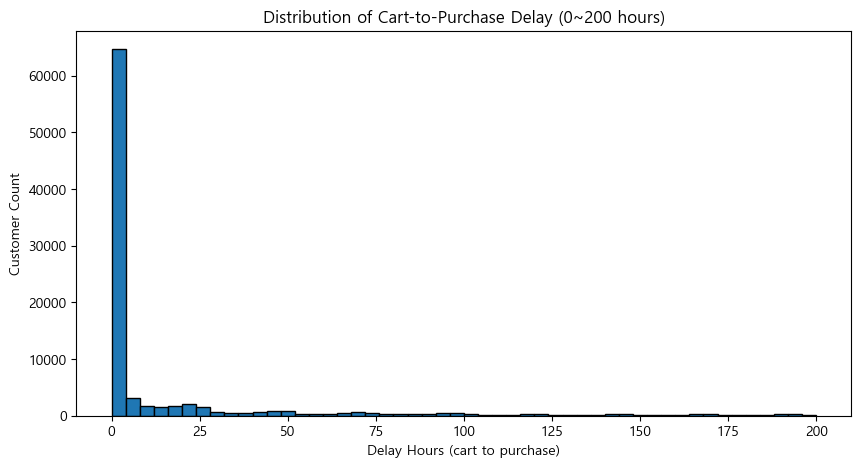

In [66]:
plt.figure(figsize=(10, 5))
plt.hist(delay_df['delay_hours'], bins=50, range=(0, 200), edgecolor='black')
plt.xlabel('Delay Hours (cart to purchase)')
plt.ylabel('Customer Count')
plt.title('Distribution of Cart-to-Purchase Delay (0~200 hours)')
plt.show()

             customer_count  repurchase_rate
delay_group                                 
1시간 이내                52260         0.106889
1~6시간                 14380         0.132267
6~24시간                 8050         0.154907
1~3일                   7709         0.173953
3~7일                   6339         0.189935
7일 이상                 20476         0.193104


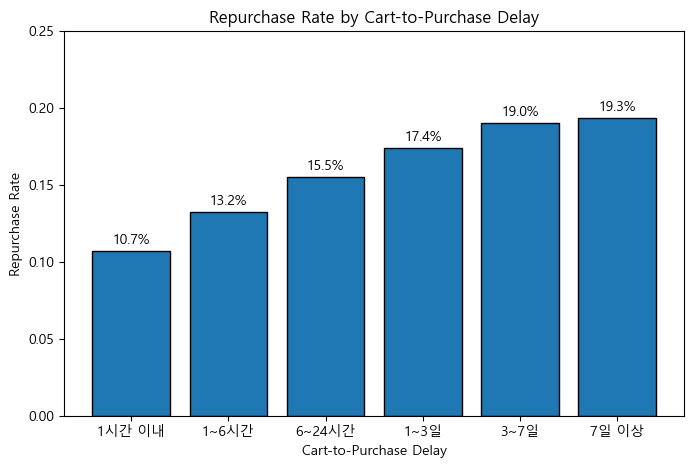

In [68]:
def assign_delay_group(hours):
    if hours <= 1:
        return '1시간 이내'
    elif hours <= 6:
        return '1~6시간'
    elif hours <= 24:
        return '6~24시간'
    elif hours <= 72:
        return '1~3일'
    elif hours <= 168:
        return '3~7일'
    else:
        return '7일 이상'

delay_df['delay_group'] = delay_df['delay_hours'].apply(assign_delay_group)

delay_stats = delay_df.groupby('delay_group').agg(
    customer_count=('user_id', 'count'),
    repurchase_rate=('repurchase', 'mean')
).reindex(['1시간 이내', '1~6시간', '6~24시간', '1~3일', '3~7일', '7일 이상'])

print(delay_stats)

plt.figure(figsize=(8, 5))
plt.bar(delay_stats.index, delay_stats['repurchase_rate'], edgecolor='black')
plt.xlabel('Cart-to-Purchase Delay')
plt.ylabel('Repurchase Rate')
plt.title('Repurchase Rate by Cart-to-Purchase Delay')
plt.ylim(0, 0.25)

for i, v in enumerate(delay_stats['repurchase_rate']):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')

plt.show()

In [74]:
# 1. 카이제곱 검정 (전체)
crosstab_h4 = pd.crosstab(delay_df['delay_group'], delay_df['repurchase'])
crosstab_h4 = crosstab_h4.reindex(['1시간 이내', '1~6시간', '6~24시간', '1~3일', '3~7일', '7일 이상'])
chi2_h4, p_h4, dof_h4, _ = chi2_contingency(crosstab_h4)
print(f'[전체] 카이제곱 통계량: {chi2_h4:.4f}, p-value: {p_h4:.6f}')

# 2. 극단값 제거 후 카이제곱 검정
Q1_val = delay_df['delay_hours'].quantile(0.25)
Q3_val = delay_df['delay_hours'].quantile(0.75)
IQR = Q3_val - Q1_val
upper = Q3_val + 1.5 * IQR
delay_filtered = delay_df[delay_df['delay_hours'] <= upper].copy()
print(f'\nIQR 상한: {upper:.1f}시간')
print(f'필터링 전: {len(delay_df)}명')
print(f'필터링 후: {len(delay_filtered)}명')

crosstab_h4f = pd.crosstab(delay_filtered['delay_group'], delay_filtered['repurchase'])
crosstab_h4f = crosstab_h4f.reindex(['1시간 이내', '1~6시간', '6~24시간', '1~3일', '3~7일', '7일 이상'])
chi2_h4f, p_h4f, _, _ = chi2_contingency(crosstab_h4f)
print(f'[극단값 제거 후] 카이제곱 통계량: {chi2_h4f:.4f}, p-value: {p_h4f:.6f}')

[전체] 카이제곱 통계량: 1185.9664, p-value: 0.000000

IQR 상한: 172.0시간
필터링 전: 109214명
필터링 후: 89070명
[극단값 제거 후] 카이제곱 통계량: 651.0499, p-value: 0.000000


가설4를 설정했을 당시, 장바구니에서 구매 전환까지 소요되는 시간이 오래 걸린 경우 그러한 경험이 고객의 구매 경험에 부정적인 영향을 끼칠 것이라 가정하였고, 그로 인해 구매 전환까지 일정 시간 이상 오래 걸리는 고객의 경우 재구매율이 낮을 것이라 생각하였다. 그러나 임계치를 설정하기 전 전체 추세에서부터, 장바구니에서 구매 전환까지 시간이 오래 걸릴수록 오히려 재구매 가능성이 높아지는 것으로 나타났다. 다만 3일 이후부터는 재구매율이 19% 내외로 정체되어, 고민 시간의 효과는 일정 수준에서 포화되는 것으로 보인다.
이는 결제까지 오래 고민한 고객이 마찰을 경험한 것이 아니라, 신중하게 구매를 결정한 고객일 가능성을 시사한다. 충분한 고민 끝에 구매한 경험은 제품에 대한 확신으로 이어져, 오히려 재구매로 연결된 것으로 해석할 수 있다.

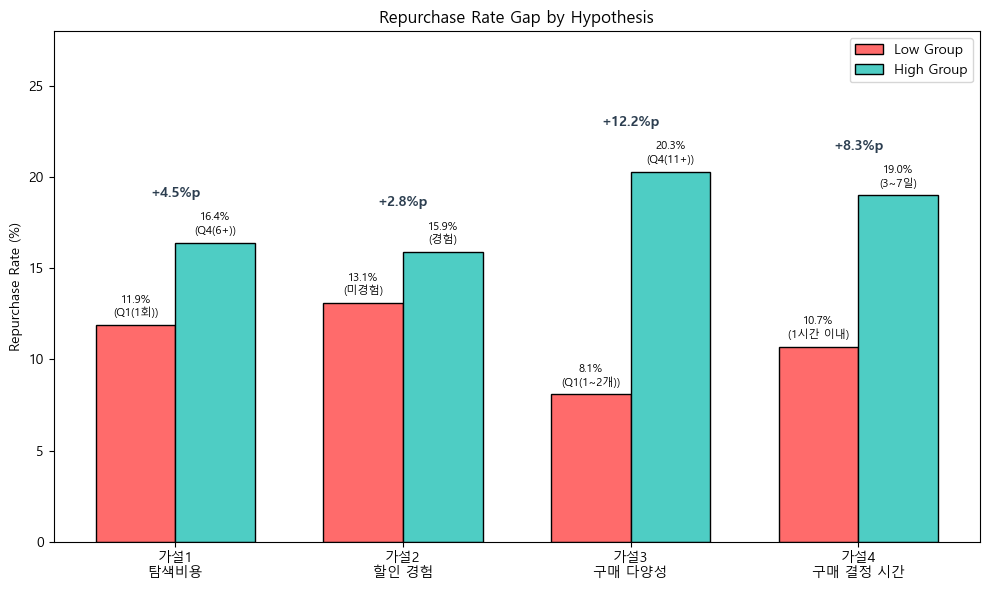

In [75]:
# 가설별 데이터
labels = ['가설1\n탐색비용', '가설2\n할인 경험', '가설3\n구매 다양성', '가설4\n구매 결정 시간']
low_rates = [11.9, 13.1, 8.1, 10.7]
high_rates = [16.4, 15.9, 20.3, 19.0]
diffs = [4.5, 2.8, 12.2, 8.3]
low_labels = ['Q1(1회)', '미경험', 'Q1(1~2개)', '1시간 이내']
high_labels = ['Q4(6+)', '경험', 'Q4(11+)', '3~7일']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, low_rates, width, label='Low Group', color='#FF6B6B', edgecolor='black')
bars2 = ax.bar(x + width/2, high_rates, width, label='High Group', color='#4ECDC4', edgecolor='black')

# 막대 위에 수치 표시
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.3,
            f'{low_rates[i]}%\n({low_labels[i]})', ha='center', va='bottom', fontsize=8)
    ax.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.3,
            f'{high_rates[i]}%\n({high_labels[i]})', ha='center', va='bottom', fontsize=8)

# 차이 표시
for i in range(len(labels)):
    ax.annotate(f'+{diffs[i]}%p',
                xy=(x[i], max(low_rates[i], high_rates[i]) + 2.5),
                ha='center', fontsize=10, fontweight='bold', color='#2C3E50')

ax.set_ylabel('Repurchase Rate (%)')
ax.set_title('Repurchase Rate Gap by Hypothesis')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 28)
ax.legend()

plt.tight_layout()
plt.show()

## 요약

- 가설 1(탐색 부담 증가)과 가설 4(구매 결정 지연)는 기각되었다.  
  두 변수는 마찰 신호라기보다 고객 관여도와 확신 형성의 신호로 해석되었다.

- 가설 2(상대적 가격 혜택 경험 부족)와 가설 3(첫 구매 상품 다양성 부족)은 채택되었다.  
  특히 첫 구매 상품 다양성 부족은 재구매율 차이가 가장 크게 나타난 핵심 변수였다.

- 이를 통해 관측기간 내 첫 구매 고객의 이탈은 구매 과정의 마찰보다,  
  첫 구매 경험의 깊이 부족과 더 밀접하게 연결되어 있음을 확인하였다.